<a href="https://colab.research.google.com/github/kimheeseo/LSCNS/blob/main/hcf_smf_g654e_fig2_comparison_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fig. 2 확장: HCF vs low-loss SMF vs G.654.E

이 Colab 노트북은 Sohanpal *et al.*의 Fig. 2 조건을 출발점으로 다음 세 광섬유의
C-band 처리량을 비교합니다.

- **HCF:** 논문 조건, 1 x 200 km
- **Low-loss SMF:** 논문의 링크 구조, 3 x 67 km (201 km)
- **G.654.E:** Fujikura FutureGuide-HSC-125 카탈로그 조건, 3 x 67 km (201 km)

공통 전송 조건은 29채널, 140 GBd DP, 150 GHz 간격, C-band 1530-1565 nm,
EDFA NF 5 dB, 트랜시버 SNR 20 dB입니다.

계산식은

$$
\mathrm{SNR}_i = \frac{P_i}
{P_{\mathrm{ASE},i}+\eta_iP_i^3+P_{\mathrm{IMI},i}+P_{\mathrm{TRX},i}},
\qquad
T_i=2R\log_2(1+\mathrm{SNR}_i)
$$

이며, 총 처리량은 29개 채널 처리량의 합입니다.

## 중요한 재현 범위

목표 논문은 SMF를 `3 x 67 km low-loss SMF`라고 명시하지만 SMF의 손실, 분산,
비선형계수 숫자는 본문에 공개하지 않습니다. 따라서 노트북은 결과를 두 가지로 분리합니다.

1. **Paper-context plot:** PDF Fig. 2에서 추출한 SMF 검증점으로 유효 ASE와 유효 GN 계수를
   피팅하여 원 논문의 녹색 곡선을 재현하고, 여기에 물리 모델 G.654.E를 추가합니다.
2. **Consistent-physics plot:** HCF, low-loss SMF, G.654.E 모두에 동일한 ASE/GN 식을 적용합니다.
   이 그래프가 섬유 파라미터의 공정한 비교 결과입니다.

논문 검증점은 재현 정확도 평가에만 사용되며, `consistent-physics` 결과에는 사용되지 않습니다.

비교 그래프에서는 섬유 간 차이를 분명히 하기 위해 HCF를 논문 중심값
\(\alpha=0.075\) dB/km, \(D=3.2\) ps/(nm km)로 사용합니다. 기존 DNANF 노트북의
C-band 파장 의존 프로파일(약 0.0743-0.0762 dB/km, 3.10-3.27 ps/(nm km))을
중심값으로 축약한 것이며, 최대 처리량 결과 차이는 매우 작습니다.


## 입력값의 출처

- Target paper: R. Sohanpal *et al.*, "On the Optimum Energy-per-bit Launch Power in
  Coherent Hollow-core Fibre Transmission Systems," arXiv:2606.17942 (2026).
- HCF/SMF benchmark model: P. Poggiolini and F. Poletti, *JLT* 40(6), 1605-1616 (2022),
  DOI: 10.1109/JLT.2021.3140114.
- G.654.E: Fujikura FutureGuide-HSC-125 catalogue. Typical values at 1550 nm:
  attenuation 0.164 dB/km, dispersion 21 ps/(nm km), dispersion slope
  0.060 ps/(nm² km), effective area 125 µm².
- Existing HCF Colab:
  https://github.com/kimheeseo/LSCNS/blob/main/paper/hcf-optimum-launch-power-reproduction/dnanf_fig2_hcf_colab.ipynb

### SMF 입력값에 대한 가정

Target paper의 `low-loss SMF` 표현을 반영하여 손실은 0.17 dB/km를 사용합니다.
분산 16.7 ps/(nm km)와 비선형계수 1.3 W⁻¹km⁻¹는 논문이 인용한 benchmark model의
SMF 값을 사용합니다. 인용 benchmark의 원래 손실값 0.20 dB/km도 코드에서 한 줄로 변경할 수 있습니다.


In [12]:
%pip -q install numpy scipy pandas matplotlib


In [13]:
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

C0 = 299_792_458.0
H_PLANCK = 6.626_070_15e-34
DB_PER_NEPER_FIELD = 8.685_889_638

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 220,
    "axes.grid": True,
    "grid.alpha": 0.30,
    "font.size": 10.5,
})


In [14]:
@dataclass(frozen=True)
class SystemConfig:
    n_channels: int = 29
    symbol_rate_gbd: float = 140.0
    channel_spacing_ghz: float = 150.0
    c_band_min_nm: float = 1530.0
    c_band_max_nm: float = 1565.0
    amplifier_noise_figure_db: float = 5.0
    transceiver_snr_db: float = 20.0

    @property
    def symbol_rate_hz(self) -> float:
        return self.symbol_rate_gbd * 1e9

    @property
    def channel_spacing_hz(self) -> float:
        return self.channel_spacing_ghz * 1e9


@dataclass(frozen=True)
class FiberScenario:
    name: str
    short_name: str
    n_spans: int
    span_length_km: float
    attenuation_1550_db_km: float
    attenuation_slope_db_km_nm: float
    dispersion_1550_ps_nm_km: float
    dispersion_slope_ps_nm2_km: float
    gamma_per_w_km: float
    imi_coefficient_db_per_km: float | None
    source_note: str
    effective_area_um2: float | None = None

    @property
    def total_length_km(self) -> float:
        return self.n_spans * self.span_length_km


SYSTEM = SystemConfig()

# HCF: target paper / existing notebook values.
HCF = FiberScenario(
    name="DNANF HCF (1 x 200 km)",
    short_name="HCF",
    n_spans=1,
    span_length_km=200.0,
    attenuation_1550_db_km=0.075,
    attenuation_slope_db_km_nm=0.0,
    dispersion_1550_ps_nm_km=3.20,
    dispersion_slope_ps_nm2_km=0.0,
    gamma_per_w_km=5e-4,
    imi_coefficient_db_per_km=-52.0,
    source_note="Target paper: alpha≈0.075, D≈3.2, gamma=5e-4, IMI=-52 dB/km",
)

# Target paper says 'low-loss SMF' but omits alpha, D and gamma.
# alpha=0.17 is the explicit low-loss assumption; D and gamma follow the cited benchmark model.
SMF = FiberScenario(
    name="Low-loss SMF (3 x 67 km)",
    short_name="SMF",
    n_spans=3,
    span_length_km=67.0,
    attenuation_1550_db_km=0.170,
    attenuation_slope_db_km_nm=0.0,
    dispersion_1550_ps_nm_km=16.7,
    dispersion_slope_ps_nm2_km=0.0,
    gamma_per_w_km=1.30,
    imi_coefficient_db_per_km=None,
    source_note="alpha=0.17 assumption; D=16.7 and gamma=1.3 from cited SMF benchmark",
)

# G.654.E nonlinear coefficient is derived from Aeff and an assumed silica n2.
SILICA_N2_M2_W = 2.6e-20
G654E_AEFF_UM2 = 125.0
G654E_GAMMA = (
    2.0 * np.pi * SILICA_N2_M2_W
    / (1550e-9 * G654E_AEFF_UM2 * 1e-12)
    * 1000.0
)

G654E = FiberScenario(
    name="G.654.E HSC-125 (3 x 67 km)",
    short_name="G.654.E",
    n_spans=3,
    span_length_km=67.0,
    attenuation_1550_db_km=0.164,
    # Derived from catalogue typical 0.164 @1550 and 0.179 @1625 nm.
    attenuation_slope_db_km_nm=(0.179 - 0.164) / (1625.0 - 1550.0),
    dispersion_1550_ps_nm_km=21.0,
    dispersion_slope_ps_nm2_km=0.060,
    gamma_per_w_km=G654E_GAMMA,
    imi_coefficient_db_per_km=None,
    source_note="Fujikura HSC-125 typical values; gamma derived from Aeff=125 µm² and n2=2.6e-20",
    effective_area_um2=G654E_AEFF_UM2,
)

FIBERS = [HCF, SMF, G654E]


In [15]:
def channel_grid(system: SystemConfig) -> tuple[np.ndarray, np.ndarray]:
    f_low = C0 / (system.c_band_max_nm * 1e-9)
    f_high = C0 / (system.c_band_min_nm * 1e-9)
    f_center = 0.5 * (f_low + f_high)
    offsets = np.arange(system.n_channels) - 0.5 * (system.n_channels - 1)
    frequency_hz = f_center + offsets * system.channel_spacing_hz
    wavelength_m = C0 / frequency_hz
    if frequency_hz[0] < f_low or frequency_hz[-1] > f_high:
        raise ValueError("The selected channel grid does not fit inside the C-band.")
    return frequency_hz, wavelength_m


def fiber_profiles(
    fiber: FiberScenario,
    wavelength_m: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    wavelength_nm = np.asarray(wavelength_m) * 1e9
    delta_nm = wavelength_nm - 1550.0
    attenuation = (
        fiber.attenuation_1550_db_km
        + fiber.attenuation_slope_db_km_nm * delta_nm
    )
    dispersion = (
        fiber.dispersion_1550_ps_nm_km
        + fiber.dispersion_slope_ps_nm2_km * delta_nm
    )
    if np.any(attenuation <= 0.0) or np.any(dispersion <= 0.0):
        raise ValueError(f"Invalid profile for {fiber.short_name}")
    return attenuation, dispersion


def dispersion_to_beta2_s2_per_km(
    dispersion_ps_nm_km: np.ndarray,
    wavelength_m: np.ndarray,
) -> np.ndarray:
    dispersion_si = np.asarray(dispersion_ps_nm_km) * 1e-6  # s/m²
    beta2_s2_per_m = -(
        np.asarray(wavelength_m) ** 2 / (2.0 * np.pi * C0)
    ) * dispersion_si
    return beta2_s2_per_m * 1000.0


def closed_form_gn_eta(
    beta2_s2_per_km: np.ndarray,
    attenuation_db_per_km: np.ndarray,
    fiber: FiberScenario,
    system: SystemConfig,
) -> np.ndarray:
    beta2 = np.abs(np.asarray(beta2_s2_per_km, dtype=float))
    alpha_field_per_km = (
        np.asarray(attenuation_db_per_km, dtype=float) / DB_PER_NEPER_FIELD
    )
    rate = system.symbol_rate_hz
    spacing = system.channel_spacing_hz
    argument = (
        np.pi**2 * beta2 * rate**2 / (4.0 * alpha_field_per_km)
        * system.n_channels ** (2.0 * rate / spacing)
    )
    return (
        fiber.n_spans
        * 4.0 * fiber.gamma_per_w_km**2
        / (27.0 * np.pi * beta2 * alpha_field_per_km * rate**2)
        * np.arcsinh(argument)
    )


def per_channel_ase_w(
    frequency_hz: np.ndarray,
    attenuation_db_per_km: np.ndarray,
    fiber: FiberScenario,
    system: SystemConfig,
) -> np.ndarray:
    span_gain = 10.0 ** (
        np.asarray(attenuation_db_per_km) * fiber.span_length_km / 10.0
    )
    noise_factor = 10.0 ** (system.amplifier_noise_figure_db / 10.0)
    return (
        fiber.n_spans
        * H_PLANCK
        * np.asarray(frequency_hz)
        * noise_factor
        * system.symbol_rate_hz
        * (span_gain - 1.0)
    )


def simulate_fiber(
    fiber: FiberScenario,
    launch_dbm: np.ndarray,
    system: SystemConfig = SYSTEM,
    ase_override_w: float | None = None,
    eta_override_per_w2: float | None = None,
) -> dict:
    launch_dbm = np.asarray(launch_dbm, dtype=float)
    frequency_hz, wavelength_m = channel_grid(system)
    attenuation, dispersion = fiber_profiles(fiber, wavelength_m)
    beta2 = dispersion_to_beta2_s2_per_km(dispersion, wavelength_m)
    eta = closed_form_gn_eta(beta2, attenuation, fiber, system)
    ase_w = per_channel_ase_w(frequency_hz, attenuation, fiber, system)

    if ase_override_w is not None:
        ase_w = np.full(system.n_channels, float(ase_override_w))
    if eta_override_per_w2 is not None:
        eta = np.full(system.n_channels, float(eta_override_per_w2))

    launch_w = 10.0 ** ((launch_dbm - 30.0) / 10.0)
    signal = launch_w[:, None]
    ase = ase_w[None, :]
    nonlinear = eta[None, :] * signal**3

    if fiber.imi_coefficient_db_per_km is None:
        imi = np.zeros_like(signal)
    else:
        imi_ratio_per_km = 10.0 ** (
            fiber.imi_coefficient_db_per_km / 10.0
        )
        imi = signal * imi_ratio_per_km * fiber.total_length_km

    transceiver = signal / (10.0 ** (system.transceiver_snr_db / 10.0))
    noise_total = ase + nonlinear + imi + transceiver
    snr = signal / noise_total
    throughput_per_channel_bps = (
        2.0 * system.symbol_rate_hz * np.log2(1.0 + snr)
    )
    total_throughput_tbps = throughput_per_channel_bps.sum(axis=1) / 1e12
    optimum_index = int(np.argmax(total_throughput_tbps))

    return {
        "fiber": fiber,
        "launch_dbm": launch_dbm,
        "frequency_hz": frequency_hz,
        "wavelength_m": wavelength_m,
        "attenuation_db_km": attenuation,
        "dispersion_ps_nm_km": dispersion,
        "beta2_s2_km": beta2,
        "eta_per_w2": eta,
        "ase_w": ase_w,
        "snr_linear": snr,
        "ase_noise_w": np.broadcast_to(ase, snr.shape),
        "nli_noise_w": nonlinear,
        "imi_noise_w": np.broadcast_to(imi, snr.shape),
        "trx_noise_w": np.broadcast_to(transceiver, snr.shape),
        "total_throughput_tbps": total_throughput_tbps,
        "optimum_index": optimum_index,
        "optimum_launch_dbm": float(launch_dbm[optimum_index]),
        "maximum_throughput_tbps": float(total_throughput_tbps[optimum_index]),
    }


## 논문 Fig. 2 검증점과 SMF 공개 누락값 처리

아래 좌표는 PDF의 벡터 경로를 축 보정하여 추출했습니다. HCF 검증점은 기존 HCF Colab과
동일한 용도입니다. SMF의 물리 파라미터가 목표 논문에 공개되지 않았기 때문에,
Fig. 2 직접 재현용 곡선에 한해 다음 두 **유효 시스템 계수**를 피팅합니다.

- 유효 ASE (P_{ASE})
- 유효 GN 계수 (eta)

이는 실측 광섬유 파라미터가 아니며, G.654.E 및 공정한 물리 비교에는 사용하지 않습니다.


In [16]:
PAPER_HCF_LAUNCH_DBM = np.array([-35., -20., -10., 0., 10., 22., 40., 48.])
PAPER_HCF_TBPS = np.array([
    1.87292751, 21.32204716, 41.62573142, 50.95120875,
    52.49881148, 52.67046429, 42.03103062, 10.44268637,
])

PAPER_SMF_LAUNCH_DBM = np.array([-16., -10., -5., 0., 5., 10., 15., 20., 24.])
PAPER_SMF_TBPS = np.array([
    1.22659286, 4.25453266, 10.11494075, 19.33266337,
    30.10752494, 37.66372844, 27.30795370, 8.64252351, 1.88922876,
])


def throughput_from_effective_coefficients(
    launch_dbm: np.ndarray,
    log10_ase_w: float,
    log10_eta_per_w2: float,
    system: SystemConfig = SYSTEM,
) -> np.ndarray:
    power_w = 10.0 ** ((np.asarray(launch_dbm) - 30.0) / 10.0)
    ase_w = 10.0 ** log10_ase_w
    eta = 10.0 ** log10_eta_per_w2
    trx = power_w / (10.0 ** (system.transceiver_snr_db / 10.0))
    snr = power_w / (ase_w + eta * power_w**3 + trx)
    return (
        system.n_channels
        * 2.0 * system.symbol_rate_hz
        * np.log2(1.0 + snr)
        / 1e12
    )


def fit_paper_smf_effective_coefficients() -> dict:
    def residual(parameters: np.ndarray) -> np.ndarray:
        model = throughput_from_effective_coefficients(
            PAPER_SMF_LAUNCH_DBM, parameters[0], parameters[1]
        )
        return np.log(model) - np.log(PAPER_SMF_TBPS)

    fit = least_squares(residual, x0=np.array([-4.0, 2.0]))
    if not fit.success:
        raise RuntimeError(f"SMF paper-equivalent fit failed: {fit.message}")
    ase_w = 10.0 ** fit.x[0]
    eta = 10.0 ** fit.x[1]
    fitted = throughput_from_effective_coefficients(
        PAPER_SMF_LAUNCH_DBM, fit.x[0], fit.x[1]
    )
    error = fitted - PAPER_SMF_TBPS
    return {
        "ase_w": float(ase_w),
        "ase_dbm": float(10.0 * np.log10(ase_w) + 30.0),
        "eta_per_w2": float(eta),
        "rmse_tbps": float(np.sqrt(np.mean(error**2))),
        "mape_percent": float(
            np.mean(np.abs(error / PAPER_SMF_TBPS)) * 100.0
        ),
    }


PAPER_SMF_EFFECTIVE = fit_paper_smf_effective_coefficients()
pd.Series(PAPER_SMF_EFFECTIVE, name="SMF Fig. 2 effective fit")


,SMF Fig. 2 effective fit
ase_w,0.000227
ase_dbm,-6.432335
eta_per_w2,90.405220
rmse_tbps,0.006027
mape_percent,0.020927


## 세 광섬유 입력값 비교

`alpha slope`은 (\alpha(\lambda)=\alpha_{1550}+s_\alpha(\lambda_{nm}-1550)),
`D slope`은 (D(\lambda)=D_{1550}+S(\lambda_{nm}-1550))에 사용됩니다.


In [17]:
def input_table(fibers: list[FiberScenario]) -> pd.DataFrame:
    rows = []
    for fiber in fibers:
        rows.append({
            "Fiber": fiber.short_name,
            "Span structure": f"{fiber.n_spans} x {fiber.span_length_km:g} km",
            "Total length (km)": fiber.total_length_km,
            "alpha@1550 (dB/km)": fiber.attenuation_1550_db_km,
            "alpha slope (dB/km/nm)": fiber.attenuation_slope_db_km_nm,
            "D@1550 (ps/nm/km)": fiber.dispersion_1550_ps_nm_km,
            "D slope (ps/nm²/km)": fiber.dispersion_slope_ps_nm2_km,
            "gamma (1/W/km)": fiber.gamma_per_w_km,
            "Aeff (µm²)": fiber.effective_area_um2,
            "IMI (dB/km)": fiber.imi_coefficient_db_per_km,
        })
    return pd.DataFrame(rows).set_index("Fiber")


INPUTS = input_table(FIBERS)
INPUTS


,Span structure,Total length (km),alpha@1550 (dB/km),alpha slope (dB/km/nm),D@1550 (ps/nm/km),D slope (ps/nm²/km),gamma (1/W/km),Aeff (µm²),IMI (dB/km)
Fiber,,,,,,,,,
HCF,1 x 200 km,200.0,0.075,0.0000,3.2,0.00,0.000500,NaN,-52.0
SMF,3 x 67 km,201.0,0.170,0.0000,16.7,0.00,1.300000,NaN,NaN
G.654.E,3 x 67 km,201.0,0.164,0.0002,21.0,0.06,0.843163,125.0,NaN


In [18]:
launch_dbm = np.linspace(-40.0, 50.0, 1801)

# Strictly consistent physical model: no paper-point fitting.
physical_results = {
    fiber.short_name: simulate_fiber(fiber, launch_dbm)
    for fiber in FIBERS
}

# Fig. 2 context: HCF is physical; only SMF uses paper-equivalent effective coefficients.
paper_context_results = {
    "HCF": physical_results["HCF"],
    "SMF": simulate_fiber(
        SMF,
        launch_dbm,
        ase_override_w=PAPER_SMF_EFFECTIVE["ase_w"],
        eta_override_per_w2=PAPER_SMF_EFFECTIVE["eta_per_w2"],
    ),
    "G.654.E": physical_results["G.654.E"],
}


def result_summary(results: dict[str, dict]) -> pd.DataFrame:
    rows = []
    for name, result in results.items():
        rows.append({
            "Fiber": name,
            "Popt (dBm/ch)": result["optimum_launch_dbm"],
            "Tmax (Tb/s)": result["maximum_throughput_tbps"],
            "mean ASE (dBm/ch)": 10.0 * np.log10(np.mean(result["ase_w"])) + 30.0,
            "mean eta (1/W²)": np.mean(result["eta_per_w2"]),
            "alpha range (dB/km)": (
                f"{np.min(result['attenuation_db_km']):.4f}-"
                f"{np.max(result['attenuation_db_km']):.4f}"
            ),
            "D range (ps/nm/km)": (
                f"{np.min(result['dispersion_ps_nm_km']):.3f}-"
                f"{np.max(result['dispersion_ps_nm_km']):.3f}"
            ),
        })
    return pd.DataFrame(rows).set_index("Fiber")


print("=== Consistent physical GN/ASE model ===")
display(result_summary(physical_results).round(4))
print("\n=== Fig. 2 paper-context model ===")
display(result_summary(paper_context_results).round(4))


=== Consistent physical GN/ASE model ===


,Popt (dBm/ch),Tmax (Tb/s),mean ASE (dBm/ch),mean eta (1/W²),alpha range (dB/km),D range (ps/nm/km)
Fiber,,,,,,
HCF,22.35,52.6714,-27.5933,0.0002,0.0750-0.0750,3.200-3.200
SMF,1.75,51.7849,-26.6199,321.1973,0.1700-0.1700,16.700-16.700
G.654.E,3.10,52.5073,-27.0920,115.4675,0.1601-0.1669,19.843-21.855



=== Fig. 2 paper-context model ===


,Popt (dBm/ch),Tmax (Tb/s),mean ASE (dBm/ch),mean eta (1/W²),alpha range (dB/km),D range (ps/nm/km)
Fiber,,,,,,
HCF,22.35,52.6714,-27.5933,0.0002,0.0750-0.0750,3.200-3.200
SMF,10.35,37.7262,-6.4323,90.4052,0.1700-0.1700,16.700-16.700
G.654.E,3.10,52.5073,-27.0920,115.4675,0.1601-0.1669,19.843-21.855


## 결과 1 - 논문 Fig. 2 문맥에 G.654.E 추가

실선은 계산곡선이고 별표는 목표 논문 PDF의 벡터 경로에서 추출한 검증점입니다.
G.654.E는 논문에 존재하지 않으므로 별도의 paper marker가 없습니다.


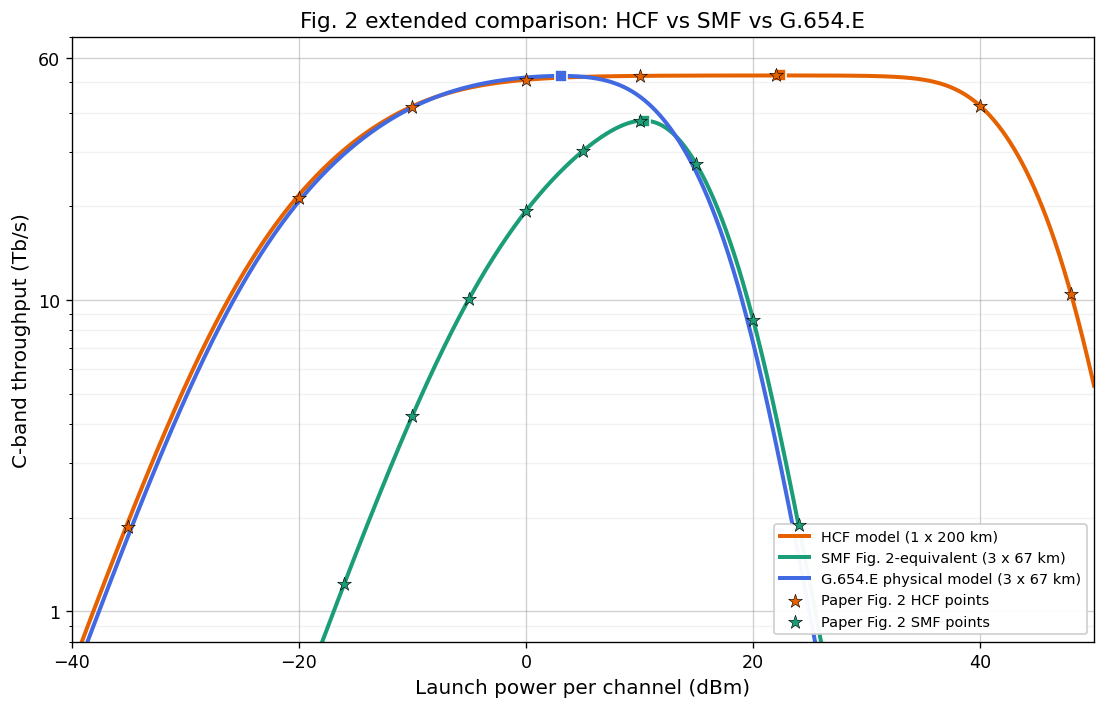

In [19]:
COLORS = {"HCF": "#e66100", "SMF": "#1b9e77", "G.654.E": "#4169e1"}


def plot_paper_context(results: dict[str, dict]) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(9.1, 5.8), constrained_layout=True)
    labels = {
        "HCF": "HCF model (1 x 200 km)",
        "SMF": "SMF Fig. 2-equivalent (3 x 67 km)",
        "G.654.E": "G.654.E physical model (3 x 67 km)",
    }
    for name, result in results.items():
        ax.plot(
            result["launch_dbm"],
            result["total_throughput_tbps"],
            lw=2.4,
            color=COLORS[name],
            label=labels[name],
        )
        i = result["optimum_index"]
        ax.plot(
            result["launch_dbm"][i],
            result["total_throughput_tbps"][i],
            marker="s",
            ms=7,
            color=COLORS[name],
            markeredgecolor="white",
            zorder=5,
        )

    ax.scatter(
        PAPER_HCF_LAUNCH_DBM, PAPER_HCF_TBPS,
        marker="*", s=75, color=COLORS["HCF"], edgecolors="black",
        linewidths=0.35, label="Paper Fig. 2 HCF points", zorder=6,
    )
    ax.scatter(
        PAPER_SMF_LAUNCH_DBM, PAPER_SMF_TBPS,
        marker="*", s=75, color=COLORS["SMF"], edgecolors="black",
        linewidths=0.35, label="Paper Fig. 2 SMF points", zorder=6,
    )

    ax.set_yscale("log")
    ax.set_xlim(-40, 50)
    ax.set_ylim(0.8, 70)
    ax.set_xticks([-40, -20, 0, 20, 40])
    ax.set_yticks([1, 10, 60], labels=["1", "10", "60"])
    ax.set_xlabel("Launch power per channel (dBm)", fontsize=12)
    ax.set_ylabel("C-band throughput (Tb/s)", fontsize=12)
    ax.set_title("Fig. 2 extended comparison: HCF vs SMF vs G.654.E", fontsize=13)
    ax.grid(True, which="major", color="#8a8a8a", alpha=0.40)
    ax.grid(True, which="minor", axis="y", alpha=0.16)
    ax.legend(loc="lower right", fontsize=8.7, framealpha=0.96)
    fig.savefig("fig2_hcf_smf_g654e_paper_context.png", bbox_inches="tight")
    return fig


fig_paper = plot_paper_context(paper_context_results)
plt.show()


## 결과 2 - 동일한 물리 모델을 적용한 공정 비교

이 그래프에서는 paper SMF fit을 사용하지 않습니다. 세 광섬유 모두 동일한 ASE 및 closed-form GN
계산을 거칩니다. 따라서 제품/섬유 파라미터 자체의 비교에는 이 결과를 사용해야 합니다.


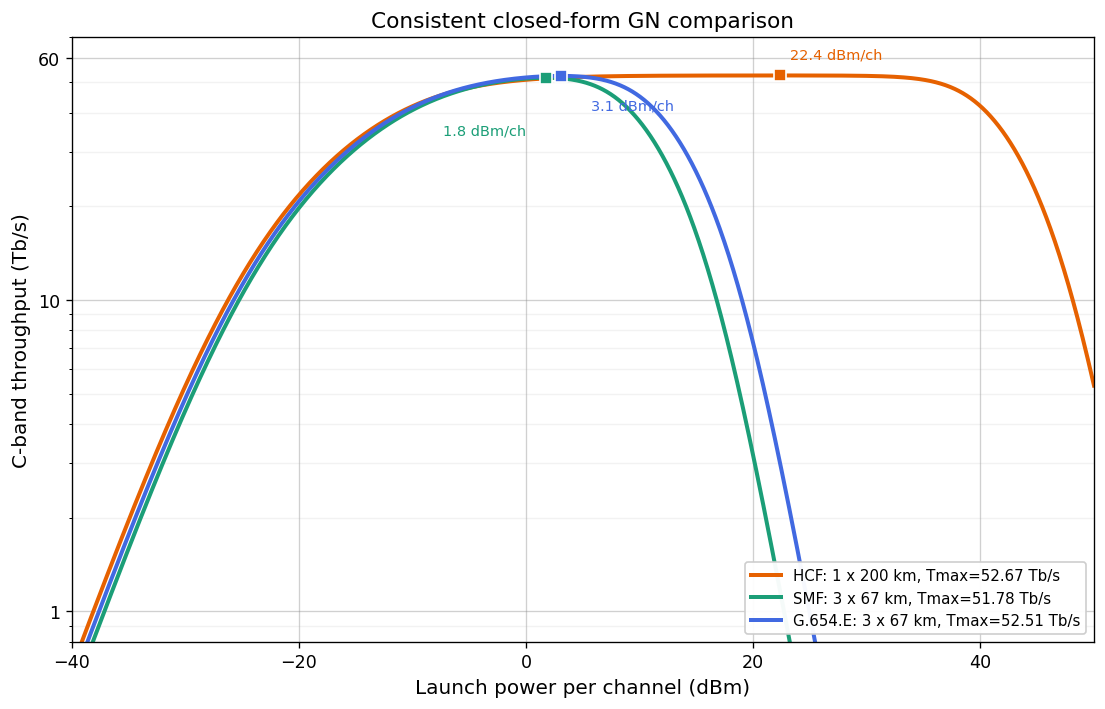

In [20]:
def plot_consistent_physics(results: dict[str, dict]) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(9.1, 5.8), constrained_layout=True)
    for name, result in results.items():
        fiber = result["fiber"]
        ax.plot(
            result["launch_dbm"],
            result["total_throughput_tbps"],
            lw=2.4,
            color=COLORS[name],
            label=(
                f"{name}: {fiber.n_spans} x {fiber.span_length_km:g} km, "
                f"Tmax={result['maximum_throughput_tbps']:.2f} Tb/s"
            ),
        )
        i = result["optimum_index"]
        ax.scatter(
            [result["launch_dbm"][i]],
            [result["total_throughput_tbps"][i]],
            marker="s", s=55, color=COLORS[name], edgecolors="white", zorder=5,
        )
        ax.annotate(
            f"{result['optimum_launch_dbm']:.1f} dBm/ch",
            xy=(result["launch_dbm"][i], result["total_throughput_tbps"][i]),
            xytext={
                "HCF": (6, 10),
                "SMF": (-62, -34),
                "G.654.E": (18, -20),
            }[name],
            textcoords="offset points", fontsize=8.7, color=COLORS[name],
        )

    ax.set_yscale("log")
    ax.set_xlim(-40, 50)
    ax.set_ylim(0.8, 70)
    ax.set_xticks([-40, -20, 0, 20, 40])
    ax.set_yticks([1, 10, 60], labels=["1", "10", "60"])
    ax.set_xlabel("Launch power per channel (dBm)", fontsize=12)
    ax.set_ylabel("C-band throughput (Tb/s)", fontsize=12)
    ax.set_title("Consistent closed-form GN comparison", fontsize=13)
    ax.grid(True, which="major", color="#8a8a8a", alpha=0.40)
    ax.grid(True, which="minor", axis="y", alpha=0.16)
    ax.legend(loc="lower right", fontsize=9, framealpha=0.96)
    fig.savefig("fig2_hcf_smf_g654e_consistent_physics.png", bbox_inches="tight")
    return fig


fig_physics = plot_consistent_physics(physical_results)
plt.show()


## 최적 운용점의 잡음 성분과 상대 성능

아래 표의 잡음값은 C-band 중심 채널에서 각 섬유의 최대 처리량 launch power를 적용한 값입니다.
`-inf`는 해당 잡음 항목이 모델에서 0이라는 뜻입니다.


In [21]:
def w_to_dbm(power_w: float) -> float:
    if power_w <= 0.0:
        return -np.inf
    return 10.0 * np.log10(power_w) + 30.0


def optimum_noise_table(results: dict[str, dict]) -> pd.DataFrame:
    center = SYSTEM.n_channels // 2
    rows = []
    smf_tmax = results["SMF"]["maximum_throughput_tbps"]
    for name, result in results.items():
        i = result["optimum_index"]
        rows.append({
            "Fiber": name,
            "Popt (dBm/ch)": result["optimum_launch_dbm"],
            "Tmax (Tb/s)": result["maximum_throughput_tbps"],
            "Tmax gain vs SMF (%)": (
                result["maximum_throughput_tbps"] / smf_tmax - 1.0
            ) * 100.0,
            "ASE (dBm)": w_to_dbm(result["ase_noise_w"][i, center]),
            "NLI (dBm)": w_to_dbm(result["nli_noise_w"][i, center]),
            "IMI (dBm)": w_to_dbm(result["imi_noise_w"][i, center]),
            "TRX noise (dBm)": w_to_dbm(result["trx_noise_w"][i, center]),
            "GSNR/SNR (dB)": 10.0 * np.log10(result["snr_linear"][i, center]),
        })
    return pd.DataFrame(rows).set_index("Fiber")


NOISE_AND_PERFORMANCE = optimum_noise_table(physical_results)
NOISE_AND_PERFORMANCE.round(3)


,Popt (dBm/ch),Tmax (Tb/s),Tmax gain vs SMF (%),ASE (dBm),NLI (dBm),IMI (dBm),TRX noise (dBm),GSNR/SNR (dB)
Fiber,,,,,,,,
HCF,22.35,52.671,1.712,-27.593,-30.568,-6.64,2.35,19.478
SMF,1.75,51.785,0.000,-26.620,-29.682,-inf,-18.25,19.145
G.654.E,3.10,52.507,1.395,-27.094,-30.082,-inf,-16.90,19.417


In [22]:
def validation_metrics(
    result: dict,
    paper_launch_dbm: np.ndarray,
    paper_tbps: np.ndarray,
) -> dict:
    model = np.interp(
        paper_launch_dbm,
        result["launch_dbm"],
        result["total_throughput_tbps"],
    )
    error = model - paper_tbps
    return {
        "RMSE (Tb/s)": np.sqrt(np.mean(error**2)),
        "MAPE (%)": np.mean(np.abs(error / paper_tbps)) * 100.0,
        "Max abs error (%)": np.max(np.abs(error / paper_tbps)) * 100.0,
    }


validation = pd.DataFrame({
    "HCF physical vs paper": validation_metrics(
        physical_results["HCF"], PAPER_HCF_LAUNCH_DBM, PAPER_HCF_TBPS
    ),
    "SMF paper-equivalent vs paper": validation_metrics(
        paper_context_results["SMF"], PAPER_SMF_LAUNCH_DBM, PAPER_SMF_TBPS
    ),
    "SMF physical assumption vs paper": validation_metrics(
        physical_results["SMF"], PAPER_SMF_LAUNCH_DBM, PAPER_SMF_TBPS
    ),
}).T
validation.round(4)


,RMSE (Tb/s),MAPE (%),Max abs error (%)
HCF physical vs paper,0.1906,0.9633,4.2264
SMF paper-equivalent vs paper,0.0060,0.0209,0.0373
SMF physical assumption vs paper,23.8066,428.8183,2219.3354


## 해석

- HCF는 낮은 Kerr 비선형성 때문에 최대 처리량 운용점이 매우 높은 launch power에 위치합니다.
- Low-loss SMF는 γ가 크기 때문에 낮은 launch power에서 NLI 제한이 나타납니다.
- G.654.E는 SMF보다 큰 (A_{eff})로 γ가 작고, 손실도 낮아 동일한 3 x 67 km 구성에서
  SMF보다 높은 처리량과 낮은 NLI를 제공합니다.
- HCF의 가장 큰 시스템 장점은 처리량뿐 아니라 200 km 단일 span을 사용하여 증폭기 수를
  줄일 수 있다는 점입니다.
- 이 계산은 목표 논문과 마찬가지로 ISRS를 무시합니다. 실제 고출력 C-band G.654.E/SMF
  설계에서는 ISRS-GN/GGN 모델, 증폭기 포화, splice/cable loss를 추가하는 것이 좋습니다.

### 입력값 변경 위치

- SMF 손실: `SMF.attenuation_1550_db_km`
- G.654.E span: `G654E.n_spans`, `G654E.span_length_km`
- G.654.E 실측 γ가 있으면: `G654E.gamma_per_w_km`
- 공통 NF/TRX SNR: `SYSTEM.amplifier_noise_figure_db`, `SYSTEM.transceiver_snr_db`
